In [498]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as ms
import pandas as pd

In [499]:
# pip install scikit-learn

In [500]:
ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')
# ens = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/pH_ensemble_ssp585_merged.nc')

ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')

bem = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/ph_ens_ssp126_biascorrected_mean.nc')
# ds4 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected.nc') 
# ds5 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected_mean.nc') 
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/REF_pH_v2.nc')
obs = xr.open_dataset('/media/athira/One Touch/final_datasets/Takahashi_clim_mask.nc')
# ds8 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Takahashi_GLOB_Grid_Dat.nc').ph


ds4= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_canesm_hist_mask.nc')
ds5= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_cesm2_hist_mask.nc')

ds6= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/ph_CESM2_historical_mask.nc')
ds7= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/ph_CMCC_historical_mask.nc')
ds8= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_gfdl-esm4_hist_mask.nc')
ds9= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/ph_IPSL_historical_mask.nc')
ds10= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_mpi-esm-hr_hist_mask.nc')
ds11= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-mm_hist_mask.nc')
ds12= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-lm_hist_mask.nc')

# ds3 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/regrid_recon_ph_1deg.nc')
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
# lat_range = slice(5, 27) 
# lon_range = slice(50, 100) 

# subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()
# subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()


In [501]:
# import xarray as xr
# import numpy as np

# # ============================================================
# # 1. Put all models into a dictionary
# # ============================================================

# models = {
#     'ds4': ds4,
#     'ds5': ds5,
#     'ds6': ds6,
#     'ds7': ds7,
#     'ds8': ds8,
#     'ds9': ds9,
#     'ds10': ds10,
#     'ds11': ds11,
#     'ds12': ds12,
#     'ens': ens
# }


# # ============================================================
# # 2. Function to calculate monthly pH trend
# # ============================================================

# def calculate_monthly_ph_rate(ds):

#     # Select only the pH variable
#     ph = ds['ph']

#     # Select 1985–2014
#     ph = ph.sel(
#         time=slice('1985-01-01', '2014-12-31')
#     )

#     monthly_rates = []

#     # --------------------------------------------------------
#     # Calculate trend separately for each calendar month
#     # --------------------------------------------------------

#     for month in range(1, 13):

#         # Select all Januarys, all Februarys, etc.
#         ph_month = ph.where(
#             ph.time.dt.month == month,
#             drop=True
#         )

#         # Linear regression:
#         # pH = slope * time + intercept
#         fit = ph_month.polyfit(
#             dim='time',
#             deg=1,
#             skipna=True
#         )

#         # Extract slope
#         slope = fit['polyfit_coefficients'].sel(
#             degree=1
#         )

#         # xarray polyfit using datetime coordinates gives
#         # slope per nanosecond, so convert to per year
#         slope = slope * (365.25 * 24 * 60 * 60 * 1e9)

#         # Add month dimension
#         slope = slope.expand_dims(
#             month=[month]
#         )

#         monthly_rates.append(slope)

#     # Combine January–December
#     rate = xr.concat(
#         monthly_rates,
#         dim='month'
#     )

#     rate.name = 'ph_rate'

#     rate.attrs['long_name'] = (
#         'Monthly linear trend of pH'
#     )

#     rate.attrs['units'] = 'pH units year-1'

#     rate.attrs['period'] = '1985-2014'

#     return rate


# # ============================================================
# # 3. Calculate pH rate for every model
# # ============================================================

# ph_rates = {}

# for name, model in models.items():

#     print(f'Calculating pH rate for {name}...')

#     ph_rates[name] = calculate_monthly_ph_rate(model)

#     print(
#         f'{name}: shape = {ph_rates[name].shape}'
#     )

In [502]:
# ds3

In [503]:
subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()

# subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# # Interpolate ds2 onto ds1 grid (lat, lon, time)
# subset_ds2_interp = subset_ds2.interp(
#     lat=subset_ds1['lat'],
#     lon=subset_ds1['lon'],
#     time=subset_ds1['time'],
#     method='linear'
# )

# Calculate mean pH
# ph_mean = xr.concat(
#     [subset_ds1['ph'], subset_ds2_interp['ph']],
#     dim='model'
# ).mean(dim='model')

subset_ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds4_sub = ds4.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds5_sub = ds5.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds6_sub = ds6.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds7_sub = ds7.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds8_sub = ds8.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds9_sub = ds9.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds10_sub = ds10.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds11_sub = ds11.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds12_sub = ds12.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
obs = obs.sel(lat=lat_range, lon=lon_range)

ens_sub = ens.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
bem_sub = bem.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()

# obs_sub = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()
# subset_ds1['time'] = subset_ds1_sub.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2_sub.indexes['time'].to_period('M').to_timestamp()


obs = obs.rename_dims({
    "time": "month",
})

# # Rename coordinates (important!)
# ds3 = ds3.rename_vars({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon",
#     "pH": "ph"
# })
# ds3_sub = ds3.sel(lat=lat_range, 
# lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()


In [504]:
subset_ds3_sub

<xarray.Dataset> Size: 534kB
Dimensions:   (month: 12, lat: 61, lon: 91)
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -28.88 -27.88 ... 28.12 29.12 29.88
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
Data variables:
    ph        (month, lat, lon) float64 533kB nan nan 8.078 ... nan nan nan

In [505]:
obs#ds8.ph#.isel(time=0).ph.plot()

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
  * time      (month) datetime64[ns] 96B 2005-01-16T12:00:00 ... 2005-12-16T1...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
Dimensions without coordinates: month
Data variables:
    ph        (month, lat, lon) float64 527kB ...

In [645]:
# lat_tgt = subset_ds8_sub.lat
# lon_tgt = subset_ds8_sub.lon
lat_tgt = subset_ds2.lat
lon_tgt = subset_ds2.lon

In [685]:
ph_mod_rg = subset_ds12_sub.interp(
    lat=lat_tgt,
    lon=lon_tgt,
    method="linear"
)


In [686]:
# ph_obs_mon = ds3_sub.assign_coords(
#     month=ds3_sub.time.dt.month
# ).swap_dims({"time": "month"}).drop("time")


In [687]:
ph_mod = subset_ds12_sub.ph.sel(lev=ph_mod_rg.lev.values[0])  



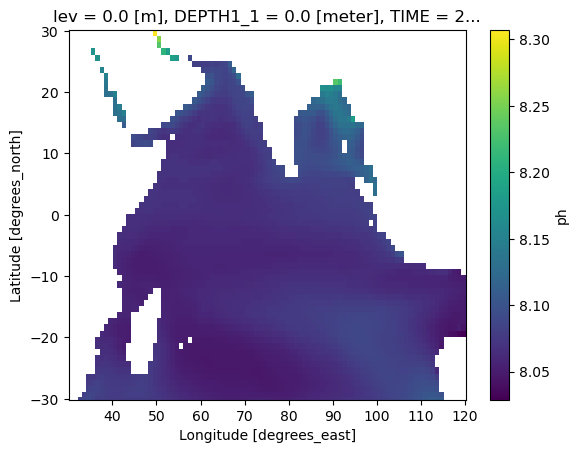

In [688]:
ph_mod[0].plot()

In [689]:
ph_mod = ph_mod.transpose('month', 'lat', 'lon')
ph_obs = subset_ds2.transpose('month', 'lat', 'lon')


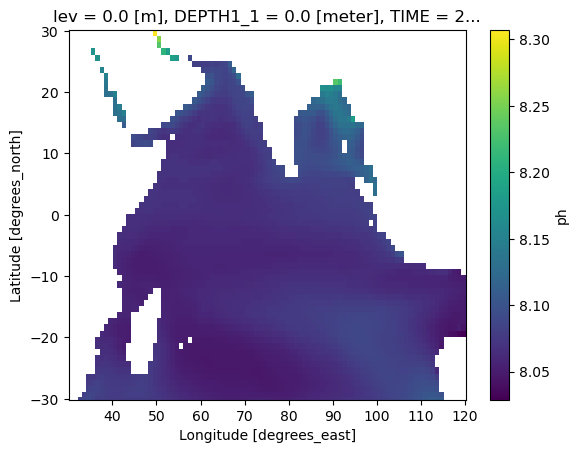

In [690]:
ph_mod[0].plot()

In [691]:
# ph_obs

In [692]:
# print(ph_mod)
# print(ph_obs)

In [693]:
# Align grids
# ph_mod, ph_obs = xr.align(ph_mod, ph_obs)

# # Create masks
# mask_mod = np.isnan(ph_mod)
# mask_obs = np.isnan(ph_obs)

# # Union mask
# common_mask = mask_mod | mask_obs

# # Apply
# ph_mod_common = ph_mod.where(~common_mask)
# ph_obs_common = ph_obs.where(~common_mask)

# # Final check
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print("Identical masks:", np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


# Make sure ph_obs is the DataArray
ph_obs = ph_obs['ph']

# Interpolate/regrid model onto observation grid
ph_mod_regrid = ph_mod.interp(
    lat=ph_obs.lat,
    lon=ph_obs.lon,
    method='nearest'
)

# Now they should have the same dimensions
print(ph_mod_regrid.shape)
print(ph_obs.shape)

# Create NaN masks
mask_mod = np.isnan(ph_mod_regrid)
mask_obs = np.isnan(ph_obs)

# Common mask: NaN if either dataset has NaN
common_mask = mask_mod | mask_obs

# Apply the same mask to both
ph_mod_common = ph_mod_regrid.where(~common_mask)
ph_obs_common = ph_obs.where(~common_mask)

# Final check
mask1_new = np.isnan(ph_mod_common)
mask2_new = np.isnan(ph_obs_common)

print("Model shape:", ph_mod_common.shape)
print("Observation shape:", ph_obs_common.shape)

print("Identical masks:", np.array_equal(mask1_new, mask2_new))
print("Model NaNs:", mask1_new.sum().item())
print("Observation NaNs:", mask2_new.sum().item())

(12, 61, 91)
(12, 61, 91)
Model shape: (12, 61, 91)
Observation shape: (12, 61, 91)
Identical masks: True
Model NaNs: 29352
Observation NaNs: 29352


In [694]:
# print(ph_obs_final.shape)
# print(ph_mod_final.shape)

# print(np.isnan(ph_obs_final).sum().item(),
#       np.isnan(ph_mod_final).sum().item())
# mask1 = np.isnan(ph_mod_final.ph)
# mask2 = np.isnan(ph_obs_final.ph)

# same_nan_mask = np.array_equal(mask1, mask2)

# print("NaN masks identical:", same_nan_mask)
# print("NaNs in ds1:", mask1.sum().item())
# print("NaNs in ds2:", mask2.sum().item())
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print(np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


In [695]:
def Taylor_skill(ref, mod):
    ref = np.array(ref)
    mod = np.array(mod)
    std_ratio = np.std(mod) / np.std(ref)
    corr = np.corrcoef(ref.flatten(), mod.flatten())[0, 1]
    tss = ((1 + corr) ** 2) / ((std_ratio + 1 / std_ratio) ** 2)
    return tss

# Apply spatially using xarray
def calculate_tss_spatially(ref_ds, mod_ds):

    skill = xr.apply_ufunc(
        Taylor_skill,             # Function to apply
        ref_ds,                   # Reference dataset
        mod_ds,                   # Model dataset
        input_core_dims=[['month'], ['month']],  # Apply over 'year' dimension
        vectorize=True,           # Vectorize the function for broadcasting
        dask="parallelized",      # Enable Dask for large data
        output_dtypes=[float]     # Output type
    )
    return skill

In [696]:
skill_cmems = calculate_tss_spatially(ph_obs_common, ph_mod_common)

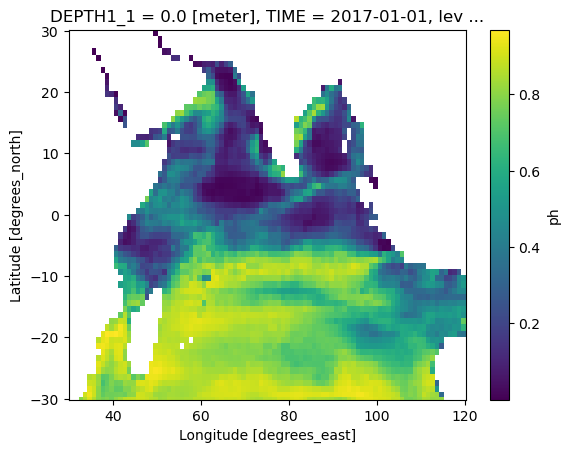

In [697]:
skill_cmems.plot()

In [698]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

skill_bias_as = skill_cmems.sel(lat=lat_range_as, lon=lon_range_as).mean()
skill_bias_as

<xarray.DataArray 'ph' ()> Size: 8B
array(0.24721507)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [699]:
lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

skill_bias_bob = skill_cmems.sel(lat=lat_range_bob, lon=lon_range_bob).mean()
skill_bias_bob

<xarray.DataArray 'ph' ()> Size: 8B
array(0.27136294)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [700]:
lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

skill_bias_cio = skill_cmems.sel(lat=lat_range_cio, lon=lon_range_cio).mean()
skill_bias_cio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.55546676)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0

In [701]:
lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

skill_bias_sio = skill_cmems.sel(lat=lat_range_sio, lon=lon_range_sio).mean()
skill_bias_sio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.79329925)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 0.0